In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("bank.csv", sep=",")

print("✅ Dataset Loaded!")
print("Total Customers:", df.shape[0])
print("Total Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())

Saving bank.csv to bank.csv
✅ Dataset Loaded!
Total Customers: 11162
Total Columns: 17

Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [3]:
# Replace unknown with NaN
df["contact"] = df["contact"].replace("unknown", np.nan)
df["poutcome"] = df["poutcome"].replace("unknown", np.nan)
df["education"] = df["education"].replace("unknown", np.nan)
df["job"] = df["job"].replace("unknown", np.nan)
df["pdays"] = df["pdays"].replace(-1, np.nan)

# Convert deposit to 1/0
df["deposit"] = df["deposit"].map({"yes": 1, "no": 0})

print("✅ Data Cleaned!")
print("Missing Values:")
print(df.isnull().sum())

✅ Data Cleaned!
Missing Values:
age             0
job            70
marital         0
education     497
default         0
balance         0
housing         0
loan            0
contact      2346
day             0
month           0
duration        0
campaign        0
pdays        8324
previous        0
poutcome     8326
deposit         0
dtype: int64


In [4]:
print("=" * 40)
print("BANKING CUSTOMER ANALYSIS REPORT")
print("=" * 40)

print("\n📊 BASIC STATISTICS")
print("Total Customers:", len(df))
print("Average Age:", round(df["age"].mean(), 1))
print("Average Balance: ₹", round(df["balance"].mean(), 2))
print("Highest Balance: ₹", df["balance"].max())
print("Lowest Balance: ₹", df["balance"].min())

print("\n💰 DEPOSIT ANALYSIS")
deposited = df["deposit"].sum()
not_deposited = len(df) - deposited
print("Customers Deposited:", deposited)
print("Customers Not Deposited:", not_deposited)
print("Deposit Rate:", round(deposited/len(df)*100, 2), "%")

print("\n👔 TOP 3 JOBS")
print(df["job"].value_counts().head(3))

print("\n🏦 ACCOUNT BALANCE BY JOB")
print(df.groupby("job")["balance"].mean().sort_values(ascending=False).head(5))

BANKING CUSTOMER ANALYSIS REPORT

📊 BASIC STATISTICS
Total Customers: 11162
Average Age: 41.2
Average Balance: ₹ 1528.54
Highest Balance: ₹ 81204
Lowest Balance: ₹ -6847

💰 DEPOSIT ANALYSIS
Customers Deposited: 5289
Customers Not Deposited: 5873
Deposit Rate: 47.38 %

👔 TOP 3 JOBS
job
management     2566
blue-collar    1944
technician     1823
Name: count, dtype: int64

🏦 ACCOUNT BALANCE BY JOB
job
retired          2417.250643
self-employed    1865.372840
management       1793.663679
entrepreneur     1621.942073
technician       1556.294569
Name: balance, dtype: float64


In [5]:
print("=" * 40)
print("DEPOSIT PATTERNS ANALYSIS")
print("=" * 40)

print("\n📊 Deposit Rate by Job:")
deposit_by_job = df.groupby("job")["deposit"].mean() * 100
print(deposit_by_job.sort_values(ascending=False).round(2))

print("\n📊 Deposit Rate by Education:")
deposit_by_edu = df.groupby("education")["deposit"].mean() * 100
print(deposit_by_edu.sort_values(ascending=False).round(2))

print("\n📊 Deposit Rate by Marital Status:")
deposit_by_marital = df.groupby("marital")["deposit"].mean() * 100
print(deposit_by_marital.sort_values(ascending=False).round(2))

DEPOSIT PATTERNS ANALYSIS

📊 Deposit Rate by Job:
job
student          74.72
retired          66.32
unemployed       56.58
management       50.70
admin.           47.30
self-employed    46.17
technician       46.08
services         39.98
housemaid        39.78
entrepreneur     37.50
blue-collar      36.42
Name: deposit, dtype: float64

📊 Deposit Rate by Education:
education
tertiary     54.11
secondary    44.74
primary      39.40
Name: deposit, dtype: float64

📊 Deposit Rate by Marital Status:
marital
single      54.35
divorced    48.11
married     43.38
Name: deposit, dtype: float64


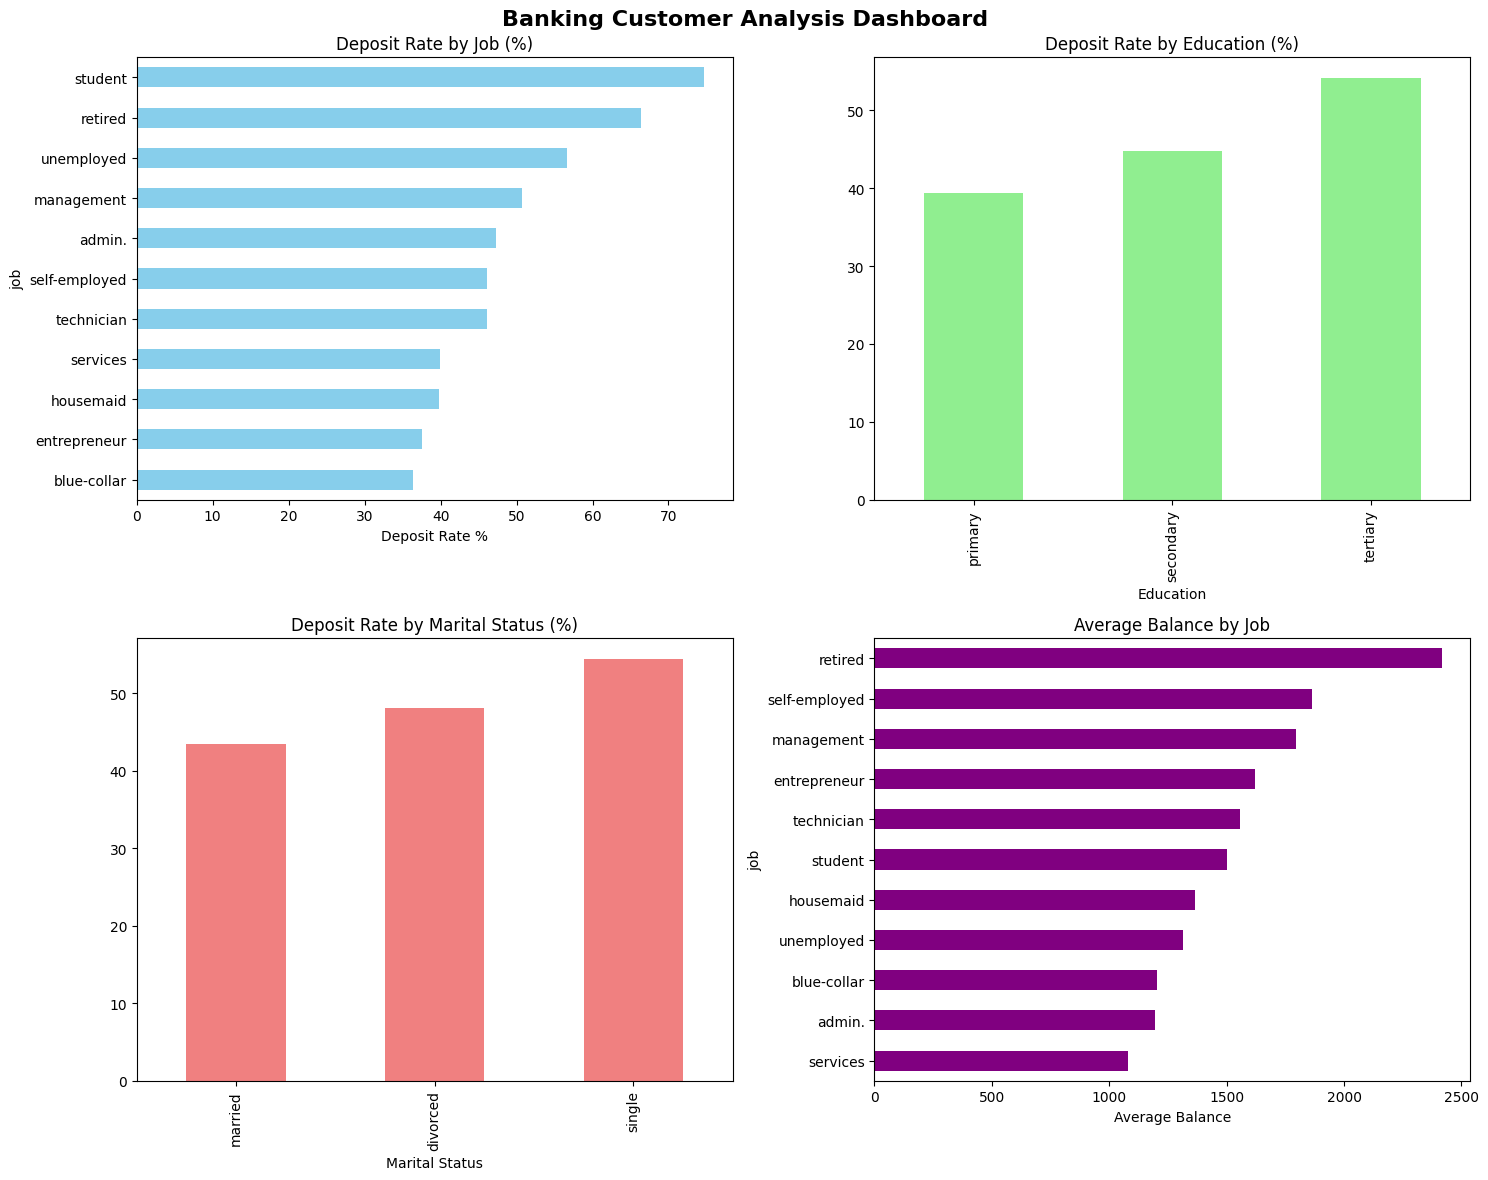

Dashboard saved! ✅


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Chart 1 - Deposit Rate by Job
deposit_by_job.sort_values().plot(
    kind="barh", ax=axes[0,0], color="skyblue")
axes[0,0].set_title("Deposit Rate by Job (%)")
axes[0,0].set_xlabel("Deposit Rate %")

# Chart 2 - Deposit Rate by Education
deposit_by_edu.sort_values().plot(
    kind="bar", ax=axes[0,1], color="lightgreen")
axes[0,1].set_title("Deposit Rate by Education (%)")
axes[0,1].set_xlabel("Education")

# Chart 3 - Deposit Rate by Marital Status
deposit_by_marital.sort_values().plot(
    kind="bar", ax=axes[1,0], color="lightcoral")
axes[1,0].set_title("Deposit Rate by Marital Status (%)")
axes[1,0].set_xlabel("Marital Status")

# Chart 4 - Balance by Job
df.groupby("job")["balance"].mean().sort_values().plot(
    kind="barh", ax=axes[1,1], color="purple")
axes[1,1].set_title("Average Balance by Job")
axes[1,1].set_xlabel("Average Balance")

plt.suptitle("Banking Customer Analysis Dashboard",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("banking_dashboard.png")
plt.show()
print("Dashboard saved! ✅")

In [7]:
print("=" * 45)
print("   BANKING ANALYSIS - KEY INSIGHTS REPORT")
print("=" * 45)

print("""
📌 INSIGHT 1 — CUSTOMER PROFILE
- Total customers analyzed: 11,162
- Average age: 41.2 years
- Average balance: ₹1,528
- Most common job: Management (2,566)

📌 INSIGHT 2 — DEPOSIT FINDINGS
- Only 47.38% customers made deposits
- 52.62% did NOT deposit
- Bank needs better marketing strategy!

📌 INSIGHT 3 — BEST TARGET CUSTOMERS
- Students → 74.72% deposit rate 🏆
- Retired → 66.32% deposit rate
- Single customers → 54.35% deposit rate
- Tertiary educated → 54.11% deposit rate

📌 INSIGHT 4 — AVOID TARGETING
- Blue-collar → only 36.42% deposit rate
- Married customers → only 43.38% rate
- Primary educated → only 39.40% rate

📌 INSIGHT 5 — BALANCE INSIGHTS
- Retired customers save most (₹2,417 avg)
- 688 customers have negative balance
- Management has worst debt (-₹6,847)

📌 RECOMMENDATION
- Target: Single + Tertiary + Student/Retired
- Launch special student savings account
- Create retirement savings scheme
- Debt recovery program for 688 customers
""")
print("=" * 45)
print("Analysis by: Kiran | Tools: Python, Pandas")
print("=" * 45)

   BANKING ANALYSIS - KEY INSIGHTS REPORT

📌 INSIGHT 1 — CUSTOMER PROFILE
- Total customers analyzed: 11,162
- Average age: 41.2 years
- Average balance: ₹1,528
- Most common job: Management (2,566)

📌 INSIGHT 2 — DEPOSIT FINDINGS
- Only 47.38% customers made deposits
- 52.62% did NOT deposit
- Bank needs better marketing strategy!

📌 INSIGHT 3 — BEST TARGET CUSTOMERS
- Students → 74.72% deposit rate 🏆
- Retired → 66.32% deposit rate
- Single customers → 54.35% deposit rate
- Tertiary educated → 54.11% deposit rate

📌 INSIGHT 4 — AVOID TARGETING
- Blue-collar → only 36.42% deposit rate
- Married customers → only 43.38% rate
- Primary educated → only 39.40% rate

📌 INSIGHT 5 — BALANCE INSIGHTS
- Retired customers save most (₹2,417 avg)
- 688 customers have negative balance
- Management has worst debt (-₹6,847)

📌 RECOMMENDATION
- Target: Single + Tertiary + Student/Retired
- Launch special student savings account
- Create retirement savings scheme
- Debt recovery program for 688 custome

In [8]:
from google.colab import files

# Download dashboard
files.download("banking_dashboard.png")

# Save report to text file
with open("banking_insights_report.txt", "w") as f:
    f.write("BANKING ANALYSIS - KEY INSIGHTS REPORT\n")
    f.write("=" * 45 + "\n")
    f.write("Total Customers: 11,162\n")
    f.write("Deposit Rate: 47.38%\n")
    f.write("Best Target: Students (74.72%)\n")
    f.write("Analysis by: Kiran | Tools: Python, Pandas\n")

files.download("banking_insights_report.txt")
print("All files downloaded! ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded! ✅
